In [26]:
import pickle
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import run_omni_v2
importlib.reload(run_omni_v2)
from run_omni_v2 import omniprediction_multiq_online_v2, OmniResult

In [27]:
d = pickle.load(open('../data/hospitalizations/preprocess_data_medianinterp_weekly.pkl', 'rb'))
forecasts_dict = d['forecasts_dict']
f_list = d['forecaster_list']
alpha_list = d['alpha_list']
dates_list = d['dates_list']
dates_list_pd = pd.to_datetime(dates_list)
Y = d['Y']
T = len(dates_list)

ens_model_names = ['COVIDhub-4_week_ensemble', 'COVIDhub-trained_ensemble', 'JHUAPL-SLPHospEns']
forecasts_wo_ens_dict = d['forecasts_dict'].copy()
for w in range(1,5):
    for ens_f in ens_model_names:
        forecasts_wo_ens_dict[w].pop(ens_f)

print(f_list)
print(alpha_list)
print(dates_list)
print(Y)

['CU-select', 'GT-DeepCOVID', 'COVIDhub-4_week_ensemble', 'COVIDhub-baseline', 'Karlen-pypm', 'JHU_IDD-CovidSP', 'MOBS-GLEAM_COVID', 'USC-SI_kJalpha', 'JHUAPL-Bucky', 'JHUAPL-SLPHospEns', 'JHUAPL-Gecko', 'COVIDhub-trained_ensemble']
[0.01, 0.025, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.975, 0.99]
Index(['2021-02-23', '2021-03-02', '2021-03-09', '2021-03-16', '2021-03-23',
       '2021-03-30', '2021-04-06', '2021-04-13', '2021-04-20', '2021-04-27',
       ...
       '2023-03-28', '2023-04-04', '2023-04-11', '2023-04-18', '2023-04-25',
       '2023-05-02', '2023-05-09', '2023-05-16', '2023-05-23', '2023-05-30'],
      dtype='str', length=119)
2021-02-23    39206.0
2021-03-02    34961.0
2021-03-09    33410.0
2021-03-16    33334.0
2021-03-23    35409.0
               ...   
2023-05-02     9721.0
2023-05-09     8832.0
2023-05-16     8328.0
2023-05-23     7579.0
2023-05-30     7310.0
Name: actual, Length: 119, dtype: float64


In [28]:
def decimal_to_str(eta):
    return str(np.round(eta, 4)).replace('.', ',')
    
def exp_name_string_v2(w, eta, suffix=''):
    return f"wk{w}_eta{decimal_to_str(eta)}{suffix}"

def exp_name_string_ql_pb(w, eta, round_Y_F, suffix=''):
    return f"wk{w}_eta{decimal_to_str(eta)}{'_orig' if not round_Y_F else ''}{suffix}"

save_folder = 'hosp0315_weekly_v2'
SAVE_DIR = f'../results/{save_folder}'
SAVE_DIR_QL_PB = f'../results/hosp0315_weekly_ql_pb'

# alpha_list_here = np.array([0.05, 0.3, 0.5, 0.7, 0.95])
alpha_list_here = alpha_list

In [29]:
####################################
no_ens = True
eta_list = np.round(np.power(10, np.arange(-2.5, 1.6, 0.25)), 4)
####################################

In [33]:
d['Y'][d['dates_list']].max()

np.float64(151023.0)

In [30]:
forecasts_dict_to_use = forecasts_wo_ens_dict if no_ens else forecasts_dict
for w in range(1,5):
    print(f"Running wk{w}...")
    for eta_multiplier in tqdm(eta_list, desc=f"Different eta_multiplier"):
        results = omniprediction_multiq_online_v2(Y=d['Y'][d['dates_list']], 
                                                forecasts_dict=forecasts_dict_to_use[w], 
                                                unit=500, 
                                                alpha_list=alpha_list_here, 
                                                eta_multiplier=eta_multiplier, 
                                                seed_list=[],
                                                verbose=False
                                                )
        exp_name = exp_name_string_v2(w, eta_multiplier, suffix=f'_noens' if no_ens else '')
        # omni_result = OmniResult(results)
        pickle.dump(results, open(f"{SAVE_DIR}/results_{exp_name}.pkl", 'wb'))
        # pickle.dump(omni_result, open(f"{SAVE_DIR}/postprocessed_{exp_name}.pkl", 'wb'))

Running wk1...


Different eta_multiplier:  94%|█████████▍| 16/17 [00:25<00:01,  1.61s/it]

Minimum of weight is too small: 3.7266343001549027e-16
Minimum of weight is too small: 5.364332133170477e-16
Minimum of weight is too small: 2.0714148094253942e-16
Minimum of weight is too small: 8.67573305294377e-17
Minimum of weight is too small: 1.0452246370863342e-17
Minimum of weight is too small: 4.3378438635449416e-16
Minimum of weight is too small: 3.3099279153976766e-16
Minimum of weight is too small: 1.2000449082135266e-16
Minimum of weight is too small: 2.2518867002685736e-17
Minimum of weight is too small: 3.8374702071533963e-16
Minimum of weight is too small: 2.3214990414200244e-16


Different eta_multiplier: 100%|██████████| 17/17 [00:27<00:00,  1.61s/it]


Running wk2...


...

Different eta_multiplier: 100%|██████████| 17/17 [00:48<00:00,  2.86s/it]


Running wk4...


Different eta_multiplier:  94%|█████████▍| 16/17 [01:03<00:03,  3.83s/it]

Minimum of weight is too small: 6.776188573797563e-16
Minimum of weight is too small: 3.661178373089495e-16
Minimum of weight is too small: 3.295280538772054e-16
Minimum of weight is too small: 2.2819455815126486e-16
Minimum of weight is too small: 2.508181707058036e-17
Minimum of weight is too small: 2.411346058534963e-16
Minimum of weight is too small: 4.0231055766002243e-16
Minimum of weight is too small: 6.282333677829859e-18
Minimum of weight is too small: 3.945799866842777e-16
Minimum of weight is too small: 4.569390735715351e-16
Minimum of weight is too small: 8.218397498325221e-16
Minimum of weight is too small: 5.701234896138913e-16
Minimum of weight is too small: 9.333963263432538e-16
Minimum of weight is too small: 1.4285387012964696e-17
Minimum of weight is too small: 5.987625338087732e-17
Minimum of weight is too small: 7.770783764195753e-19
Minimum of weight is too small: 1.1100746240208214e-16
Minimum of weight is too small: 4.798318521018811e-16
Minimum of weight is too

Different eta_multiplier: 100%|██████████| 17/17 [01:07<00:00,  3.95s/it]


In [ ]:
for w in range(1, 5):
    exp_name = exp_name_string_v2(w, 1.0, )
    results = pickle.load(open(f"{SAVE_DIR}/results_{exp_name}.pkl", 'rb'))
    ens_names = ['COVIDhub-4_week_ensemble', 'COVIDhub-trained_ensemble', 'JHUAPL-SLPHospEns']
    ens_indices = []
    for name in ens_names:
        indices = np.where(np.array(results['forecaster_names']) == name)[0][0]
        ens_indices.append(indices)
        print(f"Indices for {name}: {indices}")

    ens_preds_history = results['forecasters_preds_history'][:, :, ens_indices]
    ens_score_trace = results['forecasters_score_trace'][:, ens_indices]

    ens_d = {'ens_preds_history': ens_preds_history, 'ens_score_trace': ens_score_trace, 'ens_names': ens_names}
    pickle.dump(ens_d, open(f"../results/{SAVE_DIR}/wk{w}_ens_results.pkl", 'wb'))

IndexError: index 0 is out of bounds for axis 0 with size 0

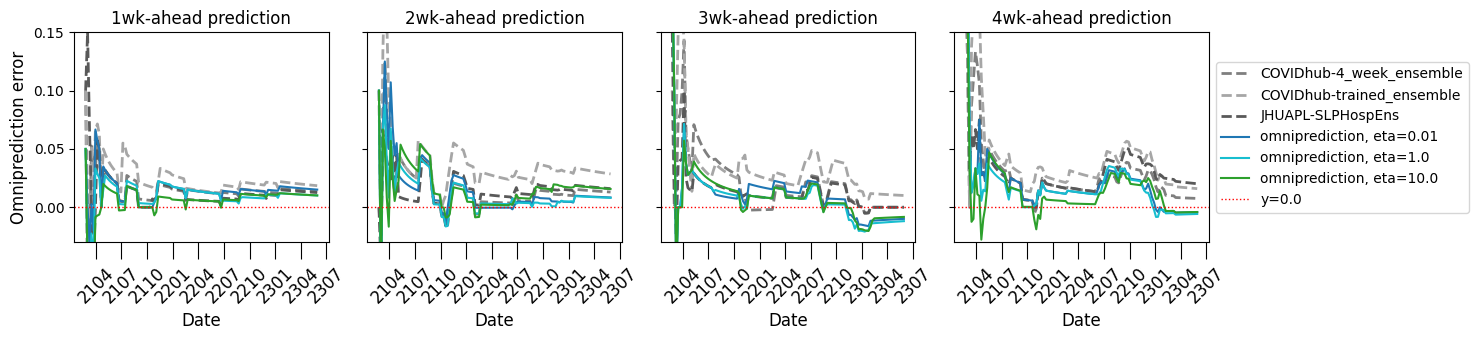

In [23]:
from utils import color_func
import matplotlib.dates as mdates
dates_list = pd.to_datetime(d['dates_list'])
T = len(dates_list)

def exp_name_string_ql_pb(w, eta, round_Y_F, suffix=''):
    return f"wk{w}_eta{decimal_to_str(eta)}{'_orig' if not round_Y_F else ''}{suffix}"

eta_list = np.round(np.power(10, np.arange(-2.5, 1.6, 0.25)), 4)
eta_list_small = np.round(np.power(10, [-2.0, 0.0, 1.0]), 4)

ens_colors = ['#7f7f7f', '#a6a6a6', '#595959']
eta_colors = ['#1f77b4', '#17becf', '#2ca02c']


fig, ax = plt.subplots(1, 4, figsize=(15, 3.5), sharey='row')
ax[0].set_ylabel('Omniprediction error', fontsize=12)
for w in range(1,5):
    ax[w-1].set_xlabel('Date', fontsize=12)
    ax[w-1].xaxis.set_major_formatter(mdates.DateFormatter('%y%m'))
    results = pickle.load(open(f"{SAVE_DIR}/results_{exp_name_string_v2(w, 1.0, '_noens')}.pkl", 'rb'))
    bfst = results['best_forecaster_score_trace']

    ens_results = pickle.load(open(f"../results/{SAVE_DIR}/wk{w}_ens_results.pkl", 'rb'))
    for eix, e_name in enumerate(ens_results['ens_names']):
        ens_omni_rel_trace = (ens_results['ens_score_trace'][:,eix] - bfst)
        ax[w-1].plot(dates_list, ens_omni_rel_trace, linewidth=2, color=ens_colors[eix], linestyle='--', label=e_name)
    
    pinball_omni_trace_min_max = np.array([[np.inf]*T, [-np.inf]*T])
    for ie, eta_mult in enumerate(eta_list_small):
        exp_name = exp_name_string_v2(w, eta_mult, '_noens')
        results = pickle.load(open(f"{SAVE_DIR}/results_{exp_name}.pkl", 'rb'))
        omni_rel_trace = (results['omni_score_trace'] - bfst)
        ax[w-1].plot(dates_list, omni_rel_trace, color=eta_colors[ie], label=f'omniprediction, eta={eta_mult}')
        
    ax[w-1].axhline(0, color='red', linewidth=1, linestyle=':', label='y=0.0')
        
    # for eta_mult in np.round(np.power(10, np.arange(-1, 3.6, 0.25)), 4):    
    #     results = pickle.load(open(f"../results/hosp0315_weekly_ql_pb/results_{exp_name_string_ql_pb(w, eta_mult, True)}.pkl", 'rb'))
    #     pinball_omni_trace_min_max[0] = np.minimum(pinball_omni_trace_min_max[0], results['pinball_omni_score_trace']-bfst)
    #     pinball_omni_trace_min_max[1] = np.maximum(pinball_omni_trace_min_max[1], results['pinball_omni_score_trace']-bfst)

    # ax[w-1].fill_between(dates_list, pinball_omni_trace_min_max[0], pinball_omni_trace_min_max[1], color='gray', alpha=0.5, label='Pinball-opt')

    
    ax[w-1].set_ylim(-0.03, 0.15)
        
    # ax[w-1].set_ylim(-0.05, 0.2)
    ax[w-1].tick_params(axis='x', labelrotation=45, labelsize=12, size=12)
    if w == 4:
        ax[w-1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax[w-1].set_title(f'{w}wk-ahead prediction')

# fig.suptitle('Omniprediction error (relative to best forecaster)')
fig.tight_layout()
plt.show()

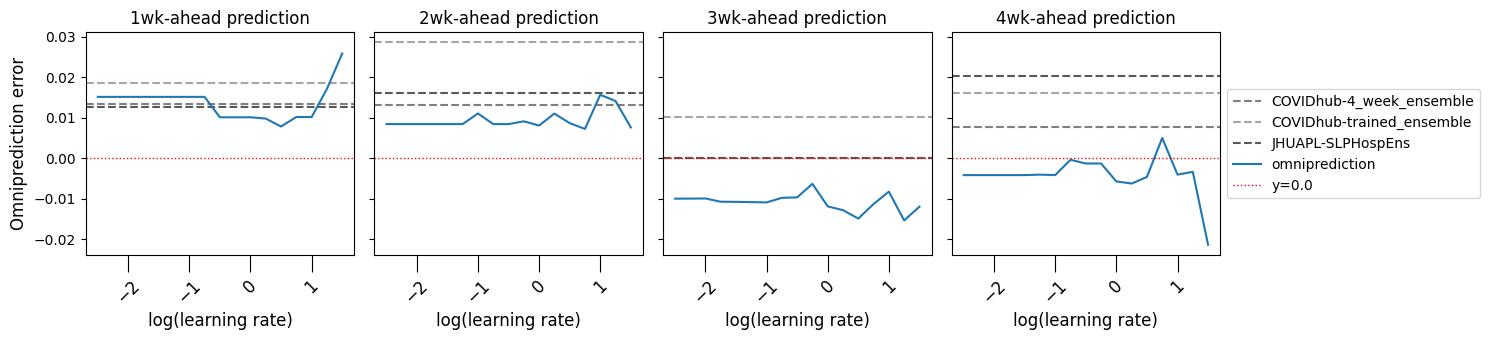

In [33]:
# learning rate sensitivity plot

fig, ax = plt.subplots(1, 4, figsize=(15, 3.5), sharey=True)
for w in range(1,5):
    results = pickle.load(open(f"{SAVE_DIR}/results_{exp_name_string_v2(w, 1.0, '_noens')}.pkl", 'rb'))
    bfst = results['best_forecaster_score_trace']

    ens_results = pickle.load(open(f"../results/{SAVE_DIR}/wk{w}_ens_results.pkl", 'rb'))
    for eix, e_name in enumerate(ens_results['ens_names']):
        ens_omni_rel_trace = (ens_results['ens_score_trace'][:,eix] - bfst)[-1]
        ax[w-1].axhline((ens_results['ens_score_trace'][:,eix] - bfst)[-1], color=ens_colors[eix], linestyle='--', label=e_name)
    
    omni_rel_trace = []
    for ie, eta in enumerate(eta_list):
        exp_name = exp_name_string_v2(w, eta, '_noens')
        results = pickle.load(open(f"{SAVE_DIR}/results_{exp_name}.pkl", 'rb'))
        omni_rel_trace.append((results['omni_score_trace'] - bfst)[-1])
    ax[w-1].plot(np.log10(eta_list), omni_rel_trace, color='#1f77b4', linestyle='-', label=f'omniprediction')
    ax[w-1].axhline(0, color='red', linewidth=1, linestyle=':', label='y=0.0')
    
    ax[w-1].set_xlabel('log(learning rate)', fontsize=12)    
    ax[w-1].set_title(f'{w}wk-ahead prediction')
    ax[w-1].tick_params(axis='x', labelrotation=45, labelsize=12, size=12)

ax[0].set_ylabel('Omniprediction error', fontsize=12)
ax[3].legend(loc='center left', bbox_to_anchor=(1, 0.5))

fig.tight_layout()
plt.show()
        

In [ ]:
for w in range(1,5):
    ax[w-1].set_xlabel('Date', fontsize=12)
    ax[w-1].xaxis.set_major_formatter(mdates.DateFormatter('%y%m'))

/var/folders/ph/sy2dklf10vj61gx7m16k6psr0000gn/T/ipykernel_52545/2973552308.py:31: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


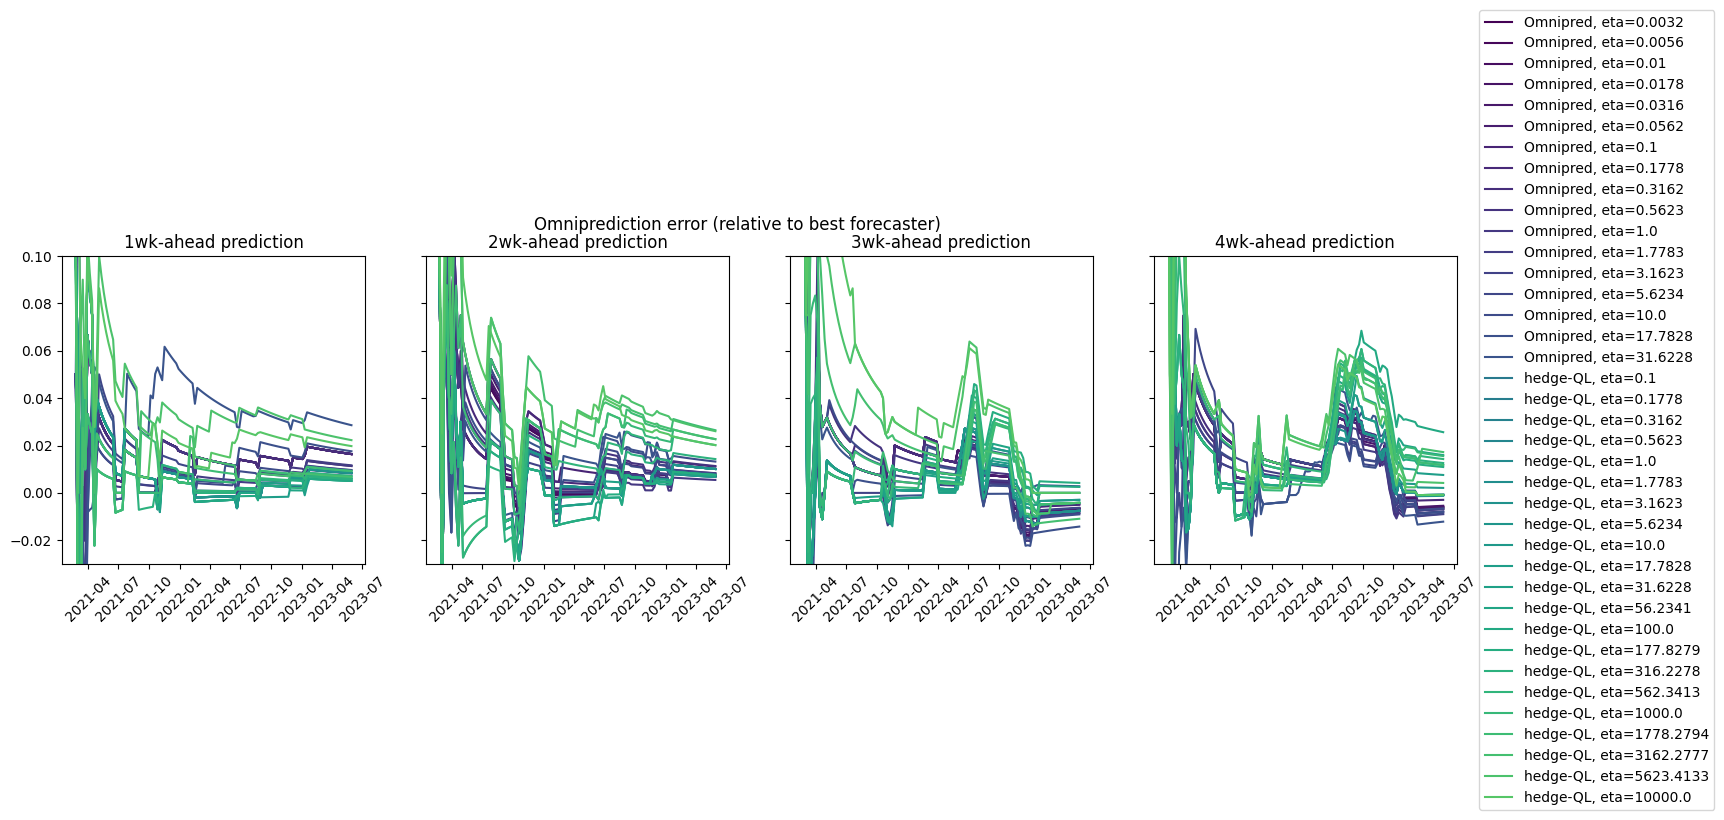

In [36]:
from numpy._core import True_
from metrics import ql_loss
from utils import color_func

eta_list_ql_pb = np.round(np.power(10, np.arange(-1, 4.1, 0.25)), 4)

fig, ax = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
for w in range(1,5):
    for ie, eta in enumerate(eta_list):
        exp_name = exp_name_string_v2(w, eta, suffix='_noens')
        results = pickle.load(open(f"{SAVE_DIR}/results_{exp_name}.pkl", 'rb'))
        T = results['T']
        Y = results['Y']
        m = results['m']
        ax[w-1].plot(dates_list_pd, results['omni_score_trace'] - results['best_forecaster_score_trace'], color = color_func(50, ie), label=f'Omnipred, eta={eta}')

    for ie, eta in enumerate(eta_list_ql_pb):
        exp_name = exp_name_string_ql_pb(w, eta, round_Y_F=True, suffix='_noens')
        results = pickle.load(open(f"{SAVE_DIR_QL_PB}/results_{exp_name}.pkl", 'rb'))
        T = results['T']
        Y = results['Y']
        m = results['m']
        ax[w-1].plot(dates_list_pd, results['pinball_omni_score_trace'] - results['best_forecaster_score_trace'], color = color_func(50, 25+ie), label=f'hedge-QL, eta={eta}')

    ax[w-1].tick_params(axis='x',rotation=45)
    ax[w-1].set_title(f'{w}wk-ahead prediction')
    ax[w-1].set_ylim(-0.03, 0.1)

ax[3].legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
fig.suptitle('Omniprediction error (relative to best forecaster)')
fig.tight_layout()
plt.show()

In [8]:
ens_results = pickle.load(open(f"../results/{SAVE_DIR}/wk{w}_ens_results.pkl", 'rb'))
ens_results.keys()

dict_keys(['ens_preds_history', 'ens_score_trace', 'ens_names'])

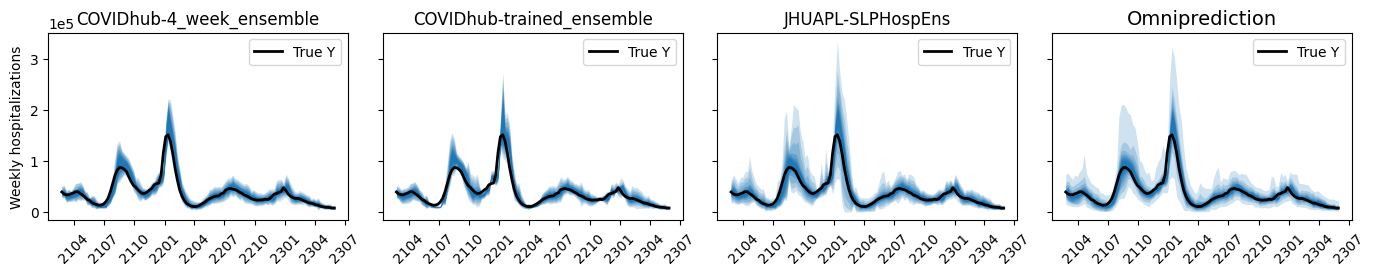

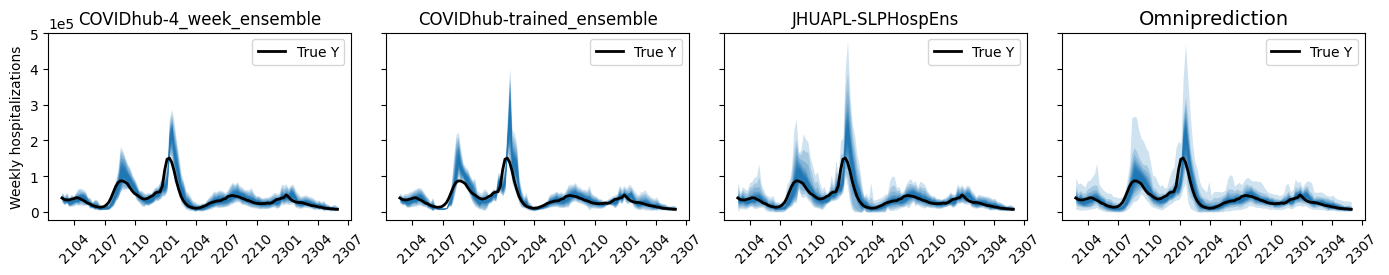

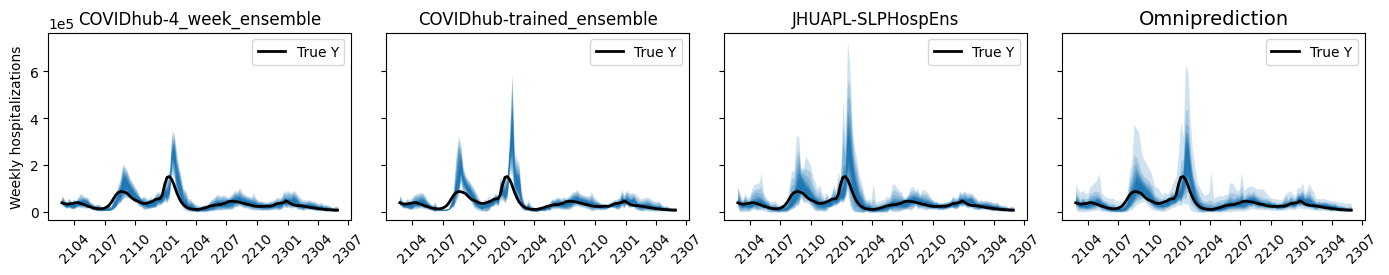

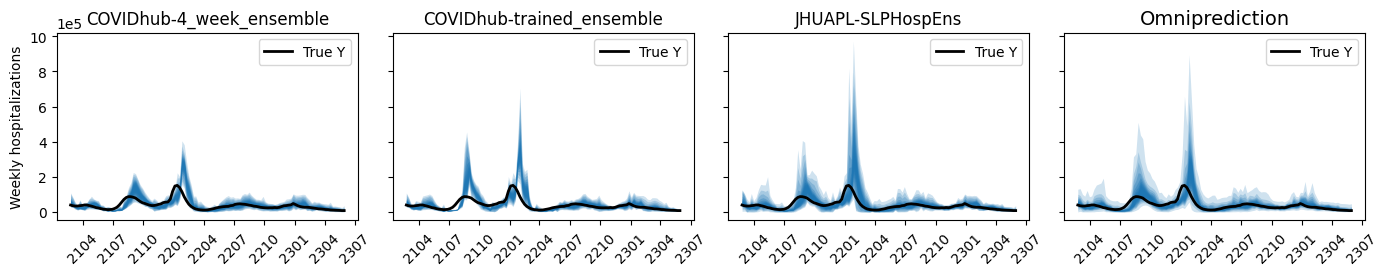

In [25]:
def quantile_plot(results, q_preds=None, color='tab:blue', results_meta=None, ax=None):
    import matplotlib.dates as mdates
    if ax is None:
        ax = plt.gca()
    if results_meta is None:
        results_meta = results

    alpha_list = results_meta['alpha_list']
    dates_list = pd.to_datetime(results_meta['dates_list'])

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%y%m'))
    ax.ticklabel_format(axis='y', style='sci', scilimits=(5,5))

    for i in range((len(alpha_list)+1) // 2):
        if alpha_list[i] + alpha_list[len(alpha_list)-1-i] != 1:
            raise ValueError("alpha_list is not symmetric")

    for ia, alpha_q in enumerate(alpha_list): 
        if alpha_q > 0.5:
            break
        alpha = 0.2 + alpha_q*6/5
        ax.fill_between(dates_list, 
                        y1=q_preds[:,ia] * results_meta['unit'], 
                        y2=q_preds[:,len(alpha_list)-1-ia] * results_meta['unit'], 
                        color=color, alpha=alpha, linewidth=0
                        )
    ax.tick_params(axis='x', rotation=45)
    ax.plot(dates_list, results_meta['Y']*results_meta['unit'], color='black', linewidth=2, label='True Y')

    return ax, q_preds




for w in range(1,5):
    fig, ax = plt.subplots(1, 4, figsize=(14, 3), sharey=True)
    exp_name = exp_name_string_v2(w, 1.0, '_noens')
    results = pickle.load(open(f"{SAVE_DIR}/results_{exp_name}.pkl", 'rb'))
    quantile_plot(results, q_preds=results['phat_history'], ax=ax[3])

    ens_results = pickle.load(open(f"../results/{SAVE_DIR}/wk{w}_ens_results.pkl", 'rb'))
    for eix, e_name in enumerate(ens_results['ens_names']):
        ax[eix].set_title(e_name, fontsize=12)
        quantile_plot(ens_results, q_preds=ens_results['ens_preds_history'][:,:,eix], results_meta=results, ax=ax[eix])

    ax[3].set_title('Omniprediction', fontsize=14)
    ax[0].set_ylabel('Weekly hospitalizations')
    for ix in range(4):
        ax[ix].legend()
    fig.tight_layout()
    plt.show()

# fig.suptitle('Quantile predictions', fontsize=16)
# fig.tight_layout()
# plt.show()

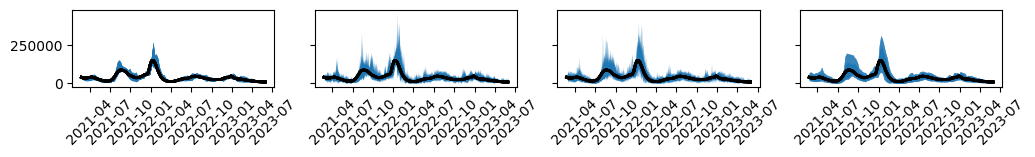

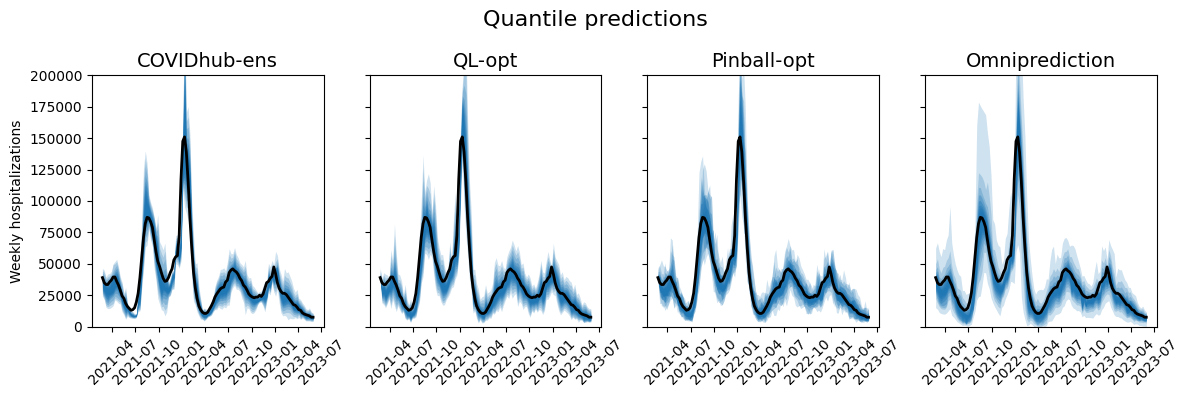

In [ ]:
n_seed = 10

q_pred_omni = np.zeros((len(d['dates_list']), len(d['alpha_list'])))
q_pred_pb = np.zeros((len(d['dates_list']), len(d['alpha_list'])))
q_pred_ql = np.zeros((len(d['dates_list']), len(d['alpha_list'])))
q_pred_ens = np.zeros((len(d['dates_list']), len(d['alpha_list'])))

fig, ax = plt.subplots(1, 4, figsize=(12, 1), sharey=True)
for seed in range(1, n_seed+1):
    omni_result = pickle.load(open(f"{SAVE_DIR}/postprocessed_{exp_name_string_v2(w=1, eta=0.5,  seed=seed)}.pkl", 'rb'))
    if seed == 10:
        fig, ax = plt.subplots(1, 4, figsize=(12, 4), sharey=True)
        omni_result.quantile_plot(ax=ax[3], q_preds=q_pred_omni/n_seed)
        omni_result.quantile_plot(ax=ax[2], q_preds=q_pred_pb/n_seed)
        omni_result.quantile_plot(ax=ax[1], q_preds=q_pred_ql/n_seed)
        omni_result.quantile_plot(ax=ax[0], q_preds=q_pred_ens/n_seed)
    else:
        ax[3], q_pred_omni = omni_result.quantile_plot(f_name='omni', ax=ax[3], q_preds_to_add=q_pred_omni)
        ax[2], q_pred_pb = omni_result.quantile_plot(f_name='pinball', ax=ax[2], q_preds_to_add=q_pred_pb)
        ax[1], q_pred_ql = omni_result.quantile_plot(f_name='ql', ax=ax[1], q_preds_to_add=q_pred_ql)
        ax[0], q_pred_ens = omni_result.quantile_plot(f_name='ens', ax=ax[0], q_preds_to_add=q_pred_ens)

ax[3].set_title('Omniprediction', fontsize=14)
ax[2].set_title('Pinball-opt', fontsize=14)
ax[1].set_title('QL-opt', fontsize=14)
ax[0].set_title('COVIDhub-ens', fontsize=14)

ax[0].set_ylabel('Weekly hospitalizations')


ax[0].set_ylim(0, 200000)

fig.suptitle('Quantile predictions', fontsize=16)
fig.tight_layout()
plt.show()

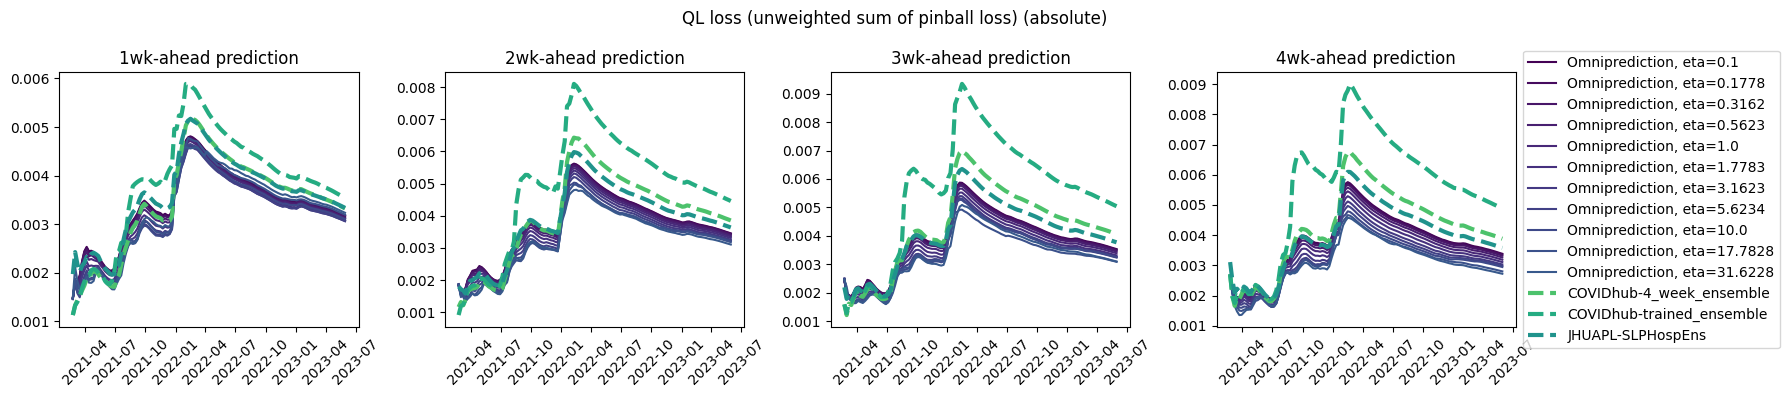

In [191]:
from metrics import ql_loss

fig, ax = plt.subplots(1, 4, figsize=(18, 4))
for w in range(1,5):
    for ie, eta in enumerate(eta_list):
        exp_name = exp_name_string_v2(w, eta, suffix='_noens')
        results = pickle.load(open(f"{SAVE_DIR}/results_{exp_name}.pkl", 'rb'))
        ens_results = pickle.load(open(f"../results/{SAVE_DIR}/wk{w}_ens_results.pkl", 'rb'))

        T = results['T']
        Y = results['Y']
        m = results['m']

        # print(results['omni_score_trace'][T-1])
        # print(omni_result.pinball_omni_score_trace[T-1])
        # print(omni_result.ql_omni_score_trace[T-1])

        # print(ql_loss(results['phat_history'], Y, results['alpha_list']).mean()/m)
    # print(ql_loss(results['pinball_preds_history'], Y, results['alpha_list']).mean()/m)
    # print(ql_loss(results['ql_preds_history'], Y, results['alpha_list']).mean()/m)

        ax[w-1].plot(pd.to_datetime(d['dates_list']), ql_loss(results['phat_history'], Y, results['alpha_list']).cumsum() / m / np.arange(1, T+1), label=f'Omniprediction, eta={eta}', color=color_func(30, ie))
    # plt.plot(pd.to_datetime(d['dates_list']), ql_loss(results['pinball_preds_history'], Y, results['alpha_list']).cumsum() / m / np.arange(1, T+1), label='Pinball-opt')
    # plt.plot(pd.to_datetime(d['dates_list']), ql_loss(results['ql_preds_history'], Y, results['alpha_list']).cumsum() / m / np.arange(1, T+1), label='QL-opt')
    for ie, e_name in enumerate(ens_results['ens_names']):
        ax[w-1].plot(pd.to_datetime(d['dates_list']), ql_loss(ens_results['ens_preds_history'][:,:,ie], Y, results['alpha_list']).cumsum() / m / np.arange(1, T+1), color=ens_colors[ie], linewidth=3, linestyle='--', label=e_name)

    ax[w-1].tick_params(axis='x',rotation=45)
    ax[w-1].set_title(f'{w}wk-ahead prediction')
ax[3].legend(loc='center left', bbox_to_anchor=(1, 0.5))
fig.suptitle('QL loss (unweighted sum of pinball loss) (absolute)')
fig.tight_layout()
plt.show()

[ 0.1     0.1778  0.3162  0.5623  1.      1.7783  3.1623  5.6234 10.
 17.7828 31.6228]
[ 0.1     0.1778  0.3162  0.5623  1.      1.7783  3.1623  5.6234 10.
 17.7828 31.6228]
[ 0.1     0.1778  0.3162  0.5623  1.      1.7783  3.1623  5.6234 10.
 17.7828 31.6228]
[ 0.1     0.1778  0.3162  0.5623  1.      1.7783  3.1623  5.6234 10.
 17.7828 31.6228]


/var/folders/ph/sy2dklf10vj61gx7m16k6psr0000gn/T/ipykernel_18046/1599522331.py:29: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


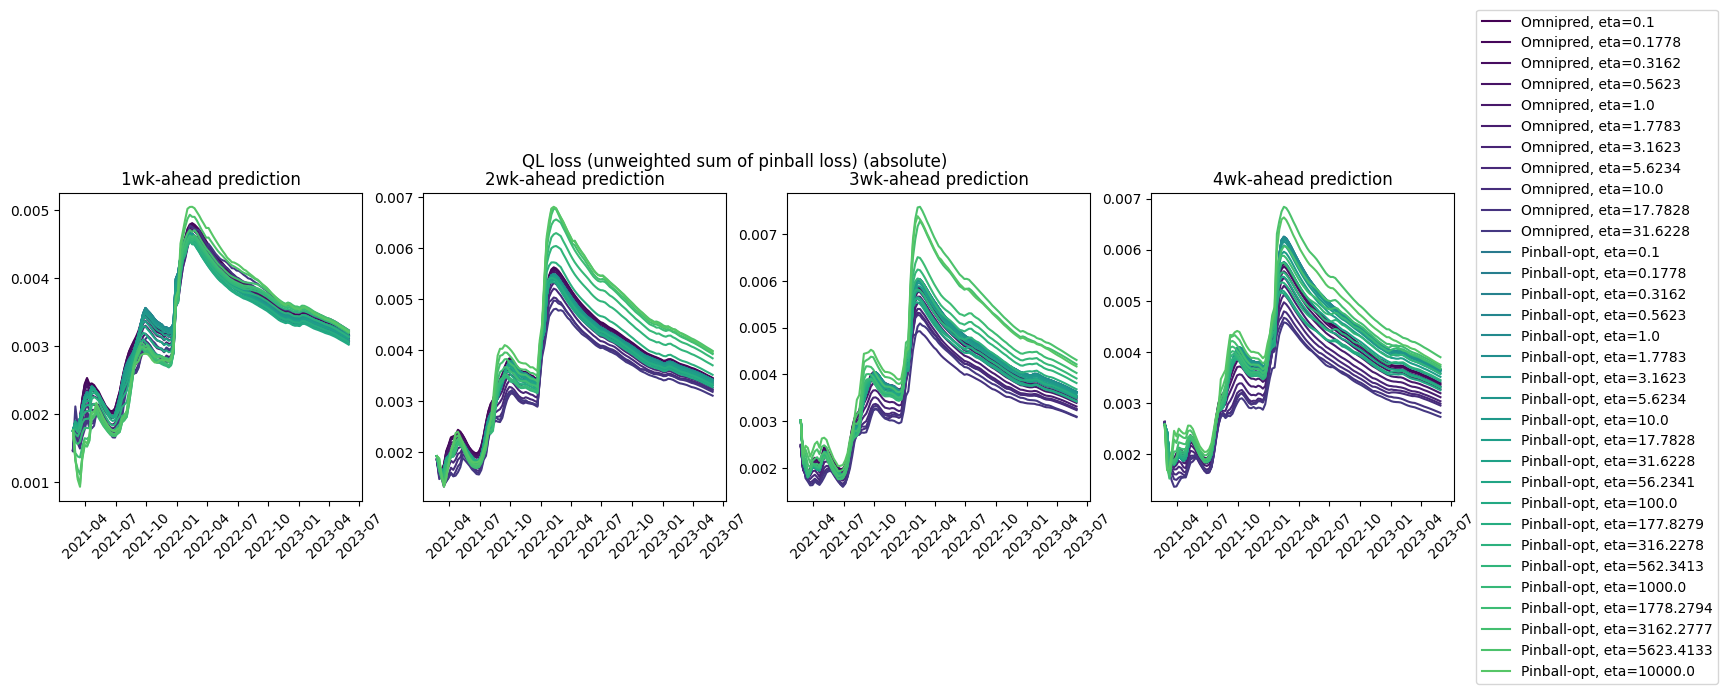

In [10]:
from metrics import ql_loss
from utils import color_func

eta_list_ql_pb = np.round(np.power(10, np.arange(-1, 4.1, 0.25)), 4)

fig, ax = plt.subplots(1, 4, figsize=(18,4))
for w in range(1,5):
    print(eta_list)
    for ie, eta in enumerate(eta_list):
        exp_name = exp_name_string_v2(w, eta, suffix='_noens')
        results = pickle.load(open(f"{SAVE_DIR}/results_{exp_name}.pkl", 'rb'))
        T = results['T']
        Y = results['Y']
        m = results['m']
        ax[w-1].plot(dates_list_pd, ql_loss(results['phat_history'], Y, results['alpha_list']).cumsum() / m / np.arange(1, T+1), color = color_func(50, ie), label=f'Omnipred, eta={eta}')

    for ie, eta in enumerate(eta_list_ql_pb):
        exp_name = exp_name_string_ql_pb(w, eta, round_Y_F=True, suffix='_noens')
        results = pickle.load(open(f"{SAVE_DIR_QL_PB}/results_{exp_name}.pkl", 'rb'))
        T = results['T']
        Y = results['Y']
        m = results['m']
        ax[w-1].plot(dates_list_pd, results['pinball_pb_loss_history'].mean(axis=1).cumsum()/np.arange(1, T+1), color = color_func(50, 25+ie), label=f'Pinball-opt, eta={eta}')

    ax[w-1].tick_params(axis='x',rotation=45)
    ax[w-1].set_title(f'{w}wk-ahead prediction')
ax[3].legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
fig.suptitle('QL loss (unweighted sum of pinball loss) (absolute)')
fig.tight_layout()
plt.show()

In [25]:
results.keys()

dict_keys(['pinball_preds_history', 'ql_preds_history', 'ql_v_history', 'pinball_omni_score_trace', 'ql_omni_score_trace', 'pinball_omni_score_trace_rel', 'ql_omni_score_trace_rel', 'pinball_pb_loss_history', 'ql_pb_loss_history', 'forecasters_pb_loss_history', 'best_f_pb_loss_trace', 'eta', 'forecasters_preds_history', 'best_forecaster_score_trace', 'Y', 'round_Y_F', 'dates_list', 'T', 'unit', 'm', 'F', 'alpha_list', 'forecaster_names'])

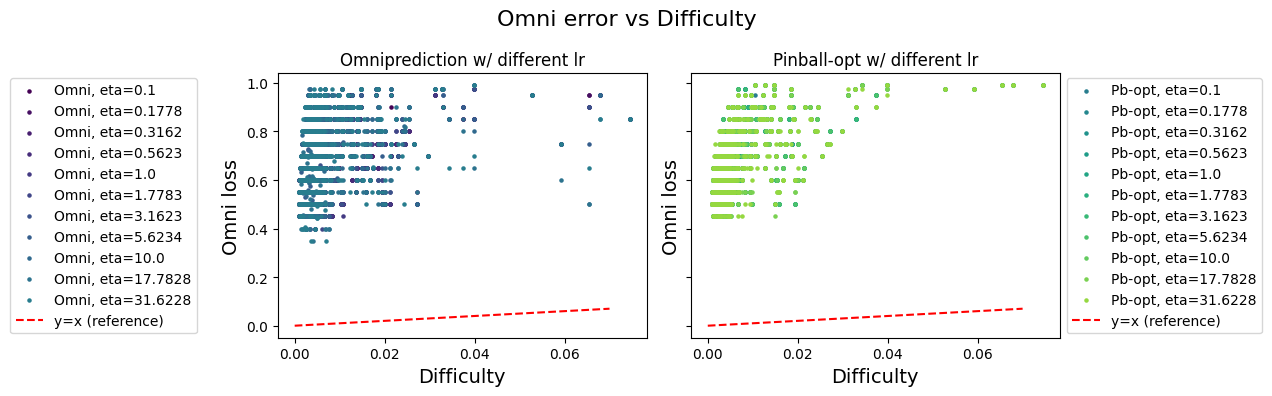

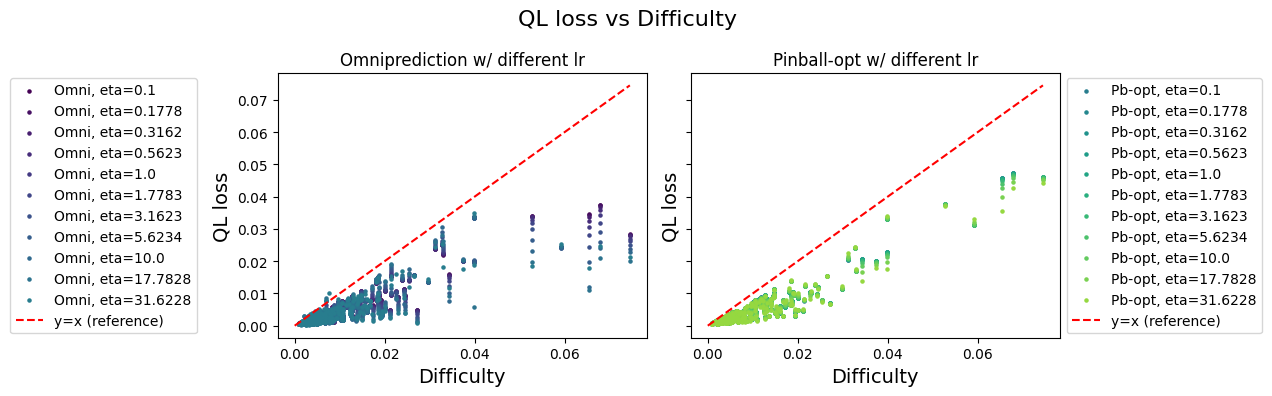

In [24]:
# difficulty and performance plot
from utils import color_func
from metrics import ql_loss

difficulty = np.zeros((4, 119))
for w in range(1,5):
    results = pickle.load(open(f"{SAVE_DIR_QL_PB}/results_{exp_name_string_ql_pb(w, 1.0, round_Y_F=True, suffix='_noens')}.pkl", 'rb'))
    difficulty[w-1, :] = np.sqrt(np.mean(results['forecasters_pb_loss_history']**2, axis=(1,2)))
    # difficulty[w-1, :] = np.mean(results['forecasters_pb_loss_history'], axis=(1,2))
    # difficulty[w-1, :] = np.min(results['forecasters_pb_loss_history'], axis=(1,2))


eta_list = np.round(np.power(10, np.arange(-1, 1.6, 0.25)), 4)
eta_list_ql_pb = np.round(np.power(10, np.arange(-1, 4.1, 0.25)), 4)

omni_omni_loss_mtx = np.zeros((len(eta_list), 4, 119))
pb_omni_loss_mtx = np.zeros((len(eta_list_ql_pb), 4, 119))

omni_ql_loss_mtx = np.zeros((len(eta_list), 4, 119))
pb_ql_loss_mtx = np.zeros((len(eta_list_ql_pb), 4, 119))



for w in range(1,5):
    for ie, eta in enumerate(eta_list):
        exp_name = exp_name_string_v2(w, eta, suffix='_noens')
        results = pickle.load(open(f"{SAVE_DIR}/results_{exp_name}.pkl", 'rb'))
        
        omni_omni_loss_mtx[ie, w-1, :] = results['omni_error_history']
        omni_ql_loss_mtx[ie, w-1, :] = ql_loss(results['phat_history'], results['Y'], results['alpha_list']) / results['m'] 

    for ie, eta in enumerate(eta_list_ql_pb):
        exp_name = exp_name_string_ql_pb(w, eta, round_Y_F=True, suffix='_noens')
        results = pickle.load(open(f"{SAVE_DIR_QL_PB}/results_{exp_name}.pkl", 'rb'))
        pb_omni_loss_mtx[ie, w-1, :] = results['pinball_omni_history']
        pb_ql_loss_mtx[ie, w-1, :] = ql_loss(results['pinball_preds_history'], results['Y'], results['alpha_list']) / results['m'] 


fig, ax = plt.subplots(1, 2, figsize=(13,4), sharey=True)
for ie, eta in enumerate(eta_list):
    ax[0].scatter(difficulty.flatten(), omni_omni_loss_mtx[ie, :, :].flatten(), s=5, color = color_func(20, ie), label=f'Omni, eta={eta}')
ax[0].set_title('Omniprediction w/ different lr')

for ie, eta in enumerate(eta_list_ql_pb):
    if ie > 10: 
        break
    ax[1].scatter(difficulty.flatten(), pb_omni_loss_mtx[ie, :, :].flatten(), s=5, color = color_func(20, 10+ie), label=f'Pb-opt, eta={eta}')
ax[1].set_title('Pinball-opt w/ different lr')

for i in range(2):
    ax[i].plot([0,0.07], [0,0.07], color='red', linestyle='--', label='y=x (reference)')
    ax[i].set_xlabel('Difficulty', fontsize=14)
    ax[i].set_ylabel('Omni loss', fontsize=14)

ax[0].legend(loc='center right', bbox_to_anchor=(-0.2, 0.5))
ax[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))

fig.suptitle('Omni error vs Difficulty', fontsize=16)
fig.tight_layout()
plt.show()


fig, ax = plt.subplots(1, 2, figsize=(13,4), sharey=True)
for ie, eta in enumerate(eta_list):
    ax[0].scatter(difficulty.flatten(), omni_ql_loss_mtx[ie, :, :].flatten(), s=5, color = color_func(20, ie), label=f'Omni, eta={eta}')
ax[0].set_title('Omniprediction w/ different lr')

for ie, eta in enumerate(eta_list_ql_pb):
    if ie > 10: 
        break
    ax[1].scatter(difficulty.flatten(), pb_ql_loss_mtx[ie, :, :].flatten(), s=5, color = color_func(20, 10+ie), label=f'Pb-opt, eta={eta}')
ax[1].set_title('Pinball-opt w/ different lr')

for i in range(2):
    ax[i].plot([0, difficulty.max()], [0,difficulty.max()], color='red', linestyle='--', label='y=x (reference)')
    ax[i].set_xlabel('Difficulty', fontsize=14)
    ax[i].set_ylabel('QL loss', fontsize=14)

ax[0].legend(loc='center right', bbox_to_anchor=(-0.2, 0.5))
ax[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))

fig.suptitle('QL loss vs Difficulty', fontsize=16)
fig.tight_layout()
plt.show()

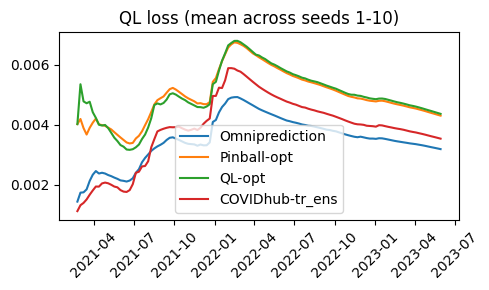

In [72]:
from metrics import ql_loss

w = 1
seed_list = list(range(1, 11))

omni_curves = []
pinball_curves = []
qlopt_curves = []
ens_curves = []

for seed in seed_list:
    exp_name = exp_name_string_v2(w, 0.5, seed=seed)
    with open(f"{SAVE_DIR}/postprocessed_{exp_name}.pkl", "rb") as f:
        omni_result = pickle.load(f)
    results = omni_result.results

    T = results["T"]
    Y = results["Y"]
    m = results["m"]
    alpha_list = results["alpha_list"]

    denom = m * np.arange(1, T + 1)
    omni_curves.append(ql_loss(results["phat_history"], Y, alpha_list).cumsum() / denom)
    pinball_curves.append(ql_loss(results["pinball_preds_history"], Y, alpha_list).cumsum() / denom)
    qlopt_curves.append(ql_loss(results["ql_preds_history"], Y, alpha_list).cumsum() / denom)
    ens_curves.append(ql_loss(results["forecasters_preds_history"][:, :, -1], Y, alpha_list).cumsum() / denom)

omni_mean = np.mean(np.vstack(omni_curves), axis=0)
pinball_mean = np.mean(np.vstack(pinball_curves), axis=0)
qlopt_mean = np.mean(np.vstack(qlopt_curves), axis=0)
ens_mean = np.mean(np.vstack(ens_curves), axis=0)

dates = pd.to_datetime(d["dates_list"])

fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(dates, omni_mean, label="Omniprediction")
ax.plot(dates, pinball_mean, label="Pinball-opt")
ax.plot(dates, qlopt_mean, label="QL-opt")
ax.plot(dates, ens_mean, label="COVIDhub-tr_ens")
ax.tick_params(axis="x", rotation=45)
ax.legend()
ax.set_title("QL loss (mean across seeds 1-10)")
plt.tight_layout()
plt.show()

In [155]:
print(ens_murphy.mean(axis=(0,1)))
print(omni_murphy.mean())


[0.00388317 0.004878   0.00357973]
0.003187765288443568


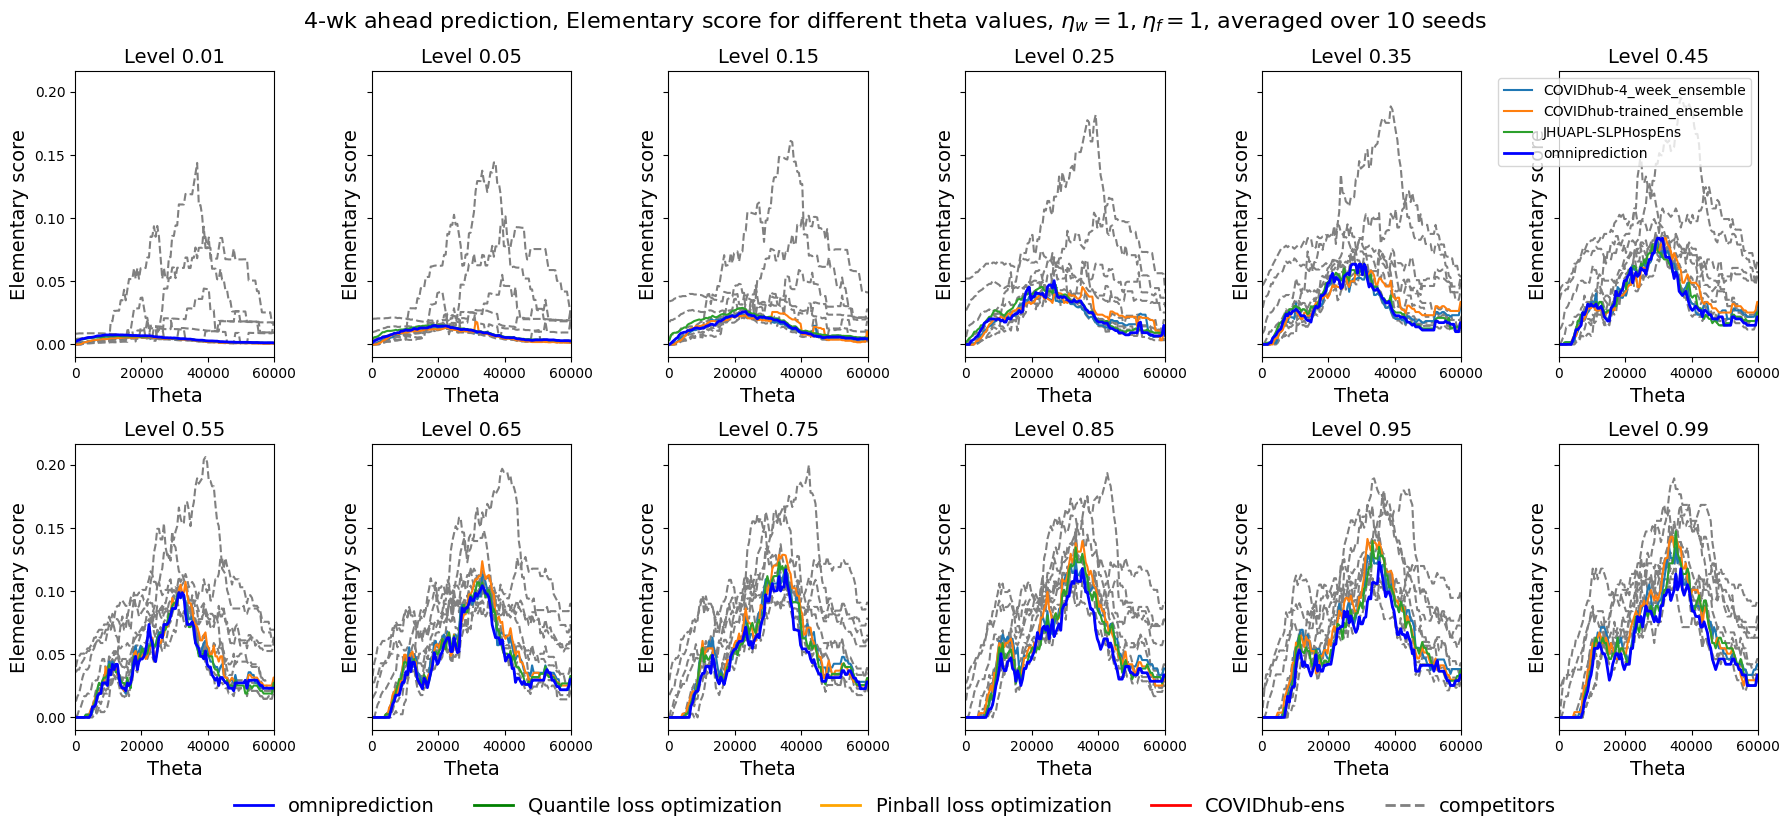

In [157]:
import importlib
import metrics
importlib.reload(metrics)
from metrics import elementary_scores_grid_T_N, elementary_scores_grid_T_N_F
from tqdm import tqdm

w=4
eta_multiplier = 1.0 

results = pickle.load(open(f"{SAVE_DIR}/results_{exp_name_string_v2(w, eta_multiplier, '_noens')}.pkl", 'rb'))
ens_results = pickle.load(open(f"../results/{SAVE_DIR}/wk{w}_ens_results.pkl", 'rb'))
thetas = results['thetas']


# results = pickle.load(open(f"{SAVE_DIR}/results_{exp_name_string_v2(w, eta_multiplier, seed)}.pkl", 'rb'))
# omni_result = OmniResult(results)

thetas = results['thetas']
unit = results['unit'] 
F = results['F']
forecaster_names = results['forecaster_names']

omni_murphy = elementary_scores_grid_T_N(p_grid_T_N=results['phat_history'], y=results['Y'].values, thetas=results['thetas'], alpha_list=results['alpha_list']).mean(axis=0)
# ql_murphy = elementary_scores_grid_T_N(p_grid_T_N=results['ql_preds_history'], y=results['Y'].values, thetas=results['thetas'], alpha_list=results['alpha_list']).mean(axis=0)
# pb_murphy = elementary_scores_grid_T_N(p_grid_T_N=results['pinball_preds_history'], y=results['Y'].values, thetas=results['thetas'], alpha_list=results['alpha_list']).mean(axis=0)
f_murphy = elementary_scores_grid_T_N_F(p_grid_T_N_F=results['forecasters_preds_history'], y=results['Y'].values, thetas=results['thetas'], alpha_list=results['alpha_list']).mean(axis=0)
ens_murphy = elementary_scores_grid_T_N_F(p_grid_T_N_F=ens_results['ens_preds_history'], y=results['Y'].values, thetas=results['thetas'], alpha_list=results['alpha_list']).mean(axis=0)

fig, ax = plt.subplots(2, 6, figsize=(18, 8), sharey=True)
ax = ax.flatten()

for ia, alpha in enumerate(alpha_list[::2]):
    # df = omni_result.single_q_pred_df(ia)
    
    for f in range(F):
        ax[ia].plot(thetas*unit, f_murphy[ia,:,f], linestyle='--', color='gray')
    for ie in range(ens_murphy.shape[2]):
        ax[ia].plot(thetas*unit, ens_murphy[ia,:,ie], linestyle='-', label=ens_results['ens_names'][ie])


    # ax[ia].plot(thetas*unit, pb_murphy[ia,:], color='orange', linewidth=2, label='Pinball loss optimization')
    # ax[ia].plot(thetas*unit, ql_murphy[ia,:], color='green', linewidth=2, label='Quantile loss optimization')
    ax[ia].plot(thetas*unit, omni_murphy[ia,:], color='blue', linewidth=2, label='omniprediction')    


    if ia == 5:
        ax[ia].legend()
    # Add a custom legend to the bottom of the entire figure
    ax[ia].set_xlabel('Theta', fontsize=14)
    ax[ia].set_ylabel('Elementary score', fontsize=14)
    ax[ia].set_title(f'Level {alpha}', fontsize=14)
    ax[ia].set_xlim(0, 60000)

from matplotlib.lines import Line2D
# custom_lines = [
#     Line2D([0], [0], color='blue', linewidth=2, label='omniprediction'),
#     Line2D([0], [0], color='green', linewidth=2, label='Quantile loss optimization'),
#     Line2D([0], [0], color='orange', linewidth=2, label='Pinball loss optimization'),
#     Line2D([0], [0], color='red', linewidth=2, label='COVIDhub-ens'),
#     Line2D([0], [0], color='gray', linewidth=2, linestyle='--', label='competitors'),
# ]
fig.legend(
    handles=custom_lines, 
    loc='lower center', 
    ncol=5, 
    bbox_to_anchor=(0.5, -0.05), 
    fontsize=14, 
    frameon=False
)

fig.suptitle(rf'{w}-wk ahead prediction, Elementary score for different theta values, $\eta_w=1, \eta_f=1$, averaged over 10 seeds', fontsize=16)
fig.tight_layout()
plt.show()

